# Bài tập lớn — Phân tích hồi quy

Đề tài: Phân tích các yếu tố ảnh hưởng đến nồng độ PM2.5 tại TP.HCM.

Câu hỏi nghiên cứu: trong số các biến khí tượng (nhiệt độ, độ ẩm), nồng
độ các chất ô nhiễm khác (TSP, CO, NO2, SO2, O3), vị trí địa lý và thời
gian, yếu tố nào ảnh hưởng đáng kể đến PM2.5? Phương pháp chính là hồi
quy tuyến tính bội. Phần mở rộng dùng hồi quy logistic cho câu hỏi
phân loại "có vượt ngưỡng WHO 25 µg/m³ không".

Dataset: HealthyAir Project (Data in Brief, 2022).


# Chương 1. Xác định bài toán

## 1.1 Bối cảnh

Bụi mịn PM2.5 là tác nhân ô nhiễm không khí nguy hiểm hàng đầu theo WHO.
TP.HCM với mật độ giao thông cao và nhiều khu công nghiệp đang đối mặt
với vấn đề PM2.5 nghiêm trọng. Hiểu rõ yếu tố nào ảnh hưởng đến PM2.5
là cơ sở để đưa ra chính sách kiểm soát ô nhiễm hiệu quả.

## 1.2 Câu hỏi nghiên cứu

Câu hỏi chính: yếu tố nào ảnh hưởng đáng kể đến PM2.5 và mức độ ảnh
hưởng của từng yếu tố ra sao?

Câu hỏi mở rộng: có thể xây dựng mô hình phân loại dự đoán giờ ô nhiễm
vượt ngưỡng WHO 25 µg/m³ dựa trên các biến đầu vào không?

## 1.3 Đối tượng và phạm vi

Đối tượng: nồng độ PM2.5 theo giờ tại 6 trạm quan trắc HealthyAir trên
địa bàn TP.HCM. Trạm 1 (ĐHQG, Thủ Đức), trạm 2/5/6 (giao thông), trạm 3
(KCN Tân Bình), trạm 4 (dân cư Bình Thạnh).

Phạm vi thời gian: từ 02/2021 đến 06/2022 với tổng 52.548 quan sát giờ.

## 1.4 Tiêu chí thành công

- R²_Adj của OLS đạt ≥ 0.5
- RMSE trên test set ≤ 10 µg/m³
- Chênh lệch R² train vs test ≤ 0.1
- AUC mô hình logistic (mở rộng) ≥ 0.8


## Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, accuracy_score
from scipy import stats
from scipy.stats import boxcox, boxcox_normmax, chi2

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:.4f}'.format

# Chương 2. Mô tả dữ liệu và phân tích khám phá

## 2.1 Tải dữ liệu

In [2]:
df = pd.read_csv('Air Quality Ho Chi Minh City.csv')
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
print(f'Số quan sát: {len(df):,}')
print(f"Khoảng thời gian: {df['date'].min()} → {df['date'].max()}")
print(f"Số trạm: {df['Station_No'].nunique()}")
df.head()

Số quan sát: 52,548
Khoảng thời gian: 2021-02-23 21:00:00 → 2022-06-21 17:00:00
Số trạm: 6


,date,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
0,2021-02-23 21:00:00,1,32.9357,15.6048,55.4314,1330.4514,112.7408,393.0000,28.3619,63.1881
1,2021-02-23 22:00:00,1,30.9324,14.5941,58.1972,1200.6035,112.3665,377.5882,28.3206,63.7735
2,2021-02-23 23:00:00,1,27.6450,13.4367,55.0294,1177.8970,112.7004,372.4767,28.3367,64.2050
3,2021-02-24 00:00:00,1,24.3800,12.3650,54.7677,1267.4760,112.4809,389.0700,28.3050,64.7350
4,2021-02-24 01:00:00,1,22.5217,11.6367,53.7862,1322.2930,114.3315,393.0000,28.3000,65.1883


## 2.2 Tiền xử lý

### 2.2.1 Xử lý giá trị thiếu

Mỗi trạm có đặc trưng ô nhiễm khác nhau (KCN khác dân cư khác giao thông),
nên ta điền giá trị thiếu bằng median của từng trạm thay vì median toàn cục.

In [3]:
numeric_cols = ['TSP','PM2.5','O3','CO','NO2','SO2','Temperature','Humidity']

print('Tỷ lệ missing trước xử lý (%):')
print((df[numeric_cols].isnull().sum() / len(df) * 100).round(3))

df[numeric_cols] = df.groupby('Station_No')[numeric_cols].transform(
    lambda x: x.fillna(x.median()))

print(f'\nSau xử lý: {df[numeric_cols].isnull().sum().sum()} missing values')

Tỷ lệ missing trước xử lý (%):
TSP            0.1140
PM2.5          0.0000
O3            20.1910
CO            17.2510
NO2           10.7830
SO2           20.9450
Temperature    8.4440
Humidity       8.4340
dtype: float64

Sau xử lý: 0 missing values


### 2.2.2 Feature engineering thời gian

Dữ liệu là chuỗi thời gian theo giờ. Ta tạo các biến phái sinh từ cột
date để khai thác các pattern thời gian:

- hour_group: 5 nhóm giờ (đêm, sáng cao điểm, ban ngày, chiều cao điểm, tối)
- is_weekend: 1 nếu thứ Bảy hoặc Chủ nhật
- is_dry_season: 1 nếu tháng 11-4 (mùa khô ở TP.HCM)

In [4]:
df['hour'] = df['date'].dt.hour
df['dow'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = (df['dow'] >= 5).astype(int)
df['is_dry_season'] = df['month'].isin([11,12,1,2,3,4]).astype(int)

def hour_group(h):
    if h < 6: return 'night'
    if h < 10: return 'morning_rush'
    if h < 16: return 'daytime'
    if h < 20: return 'evening_rush'
    return 'evening'
df['hour_group'] = df['hour'].apply(hour_group)

print(df['hour_group'].value_counts())
print(f"\nTỷ lệ cuối tuần: {df['is_weekend'].mean()*100:.1f}%")
print(f"Tỷ lệ mùa khô: {df['is_dry_season'].mean()*100:.1f}%")

hour_group
daytime         13342
night           13034
evening_rush     8813
morning_rush     8731
evening          8628
Name: count, dtype: int64

Tỷ lệ cuối tuần: 28.1%
Tỷ lệ mùa khô: 55.9%


### 2.2.3 Phân tích outlier

PM2.5 có giá trị max = 403.69 µg/m³, cao bất thường so với trung vị 17.5.
Ta cần đánh giá liệu đây là lỗi đo hay hiện tượng thực.

In [5]:
print('Percentile PM2.5:')
for p in [50, 90, 95, 99, 99.5, 99.9]:
    print(f'  {p}%: {df["PM2.5"].quantile(p/100):.2f}')
print(f'  Max: {df["PM2.5"].max():.2f}')

threshold = df['PM2.5'].quantile(0.99)
n_high = (df['PM2.5'] > threshold).sum()
print(f'\nQuan sát > P99 ({threshold:.1f}): {n_high} ({n_high/len(df)*100:.2f}%)')

Percentile PM2.5:
  50%: 17.48
  90%: 36.94
  95%: 45.98
  99%: 72.47
  99.5%: 84.77
  99.9%: 116.31
  Max: 403.69

Quan sát > P99 (72.5): 526 (1.00%)


Ta giữ các quan sát PM2.5 cao này vì đây có thể là các sự kiện ô nhiễm
thực tế (cháy rừng, kẹt xe, thời tiết bất lợi). Loại bỏ sẽ làm mất
thông tin về các tình huống cực đoan vốn là tình huống quan trọng nhất
cần dự báo.

## 2.3 Thống kê mô tả

In [6]:
desc = df[numeric_cols].describe().T
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurt()
print(desc[['mean','std','min','50%','max','skewness','kurtosis']].round(2))

                mean      std     min      50%        max  skewness  kurtosis
TSP          43.5600  35.4900  0.0000  38.8000   938.2000    3.1100   37.4500
PM2.5        21.1300  14.2300  0.0000  17.4800   403.6900    4.3100   54.7100
O3           94.9600  33.5800  0.0000  95.3700   377.2900    0.8300    3.2100
CO          963.3900 564.0600  0.0000 817.4800 21092.5700    4.6600   58.9900
NO2         100.4700  68.5900  0.0000  83.9900   461.0900    1.2700    1.3300
SO2         241.6300 107.9100  2.6200 230.1200   699.9800    0.7800    0.9200
Temperature  27.9800   4.1400 18.4900  28.4800    42.8100   -0.4000   -0.3000
Humidity     63.9900  24.6500 11.3200  68.6500    99.2800   -1.1500    0.2300


PM2.5 có skewness = 4.31, kurtosis = 28.6 — phân phối lệch phải mạnh,
đuôi rất dày. TSP cũng lệch phải nhưng nhẹ hơn. Nhiệt độ và độ ẩm có
phân phối gần đối xứng. Phân phối lệch của PM2.5 gợi ý có thể cần biến
đổi log; ta sẽ thử ở mục 3.9.

## 2.4 Phân phối các biến

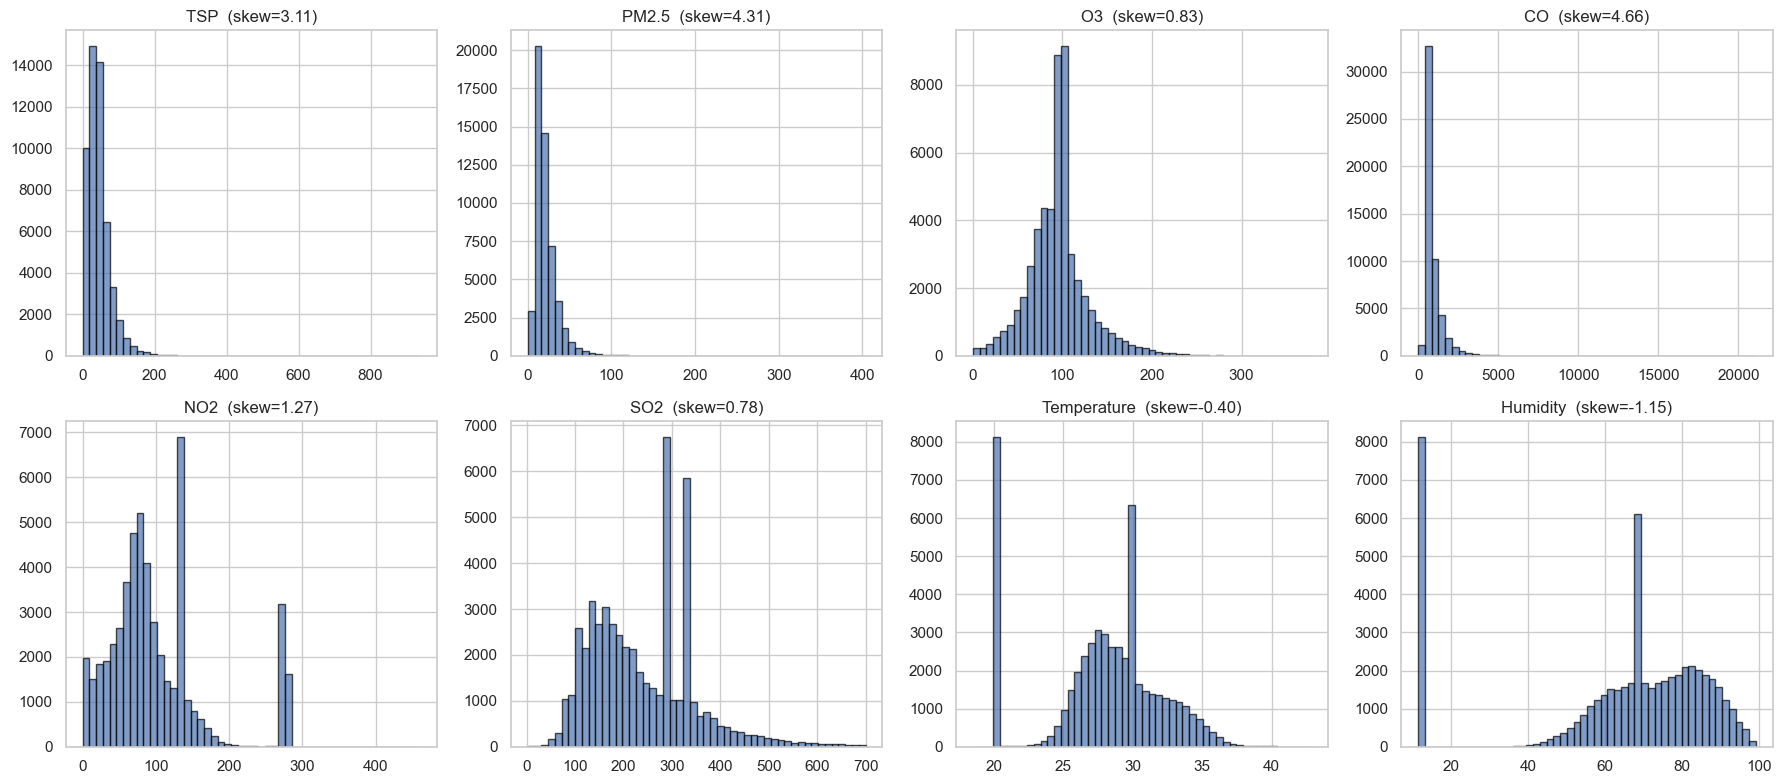

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}  (skew={df[col].skew():.2f})')
plt.tight_layout(); plt.show()

## 2.5 Quan hệ giữa các biến với PM2.5

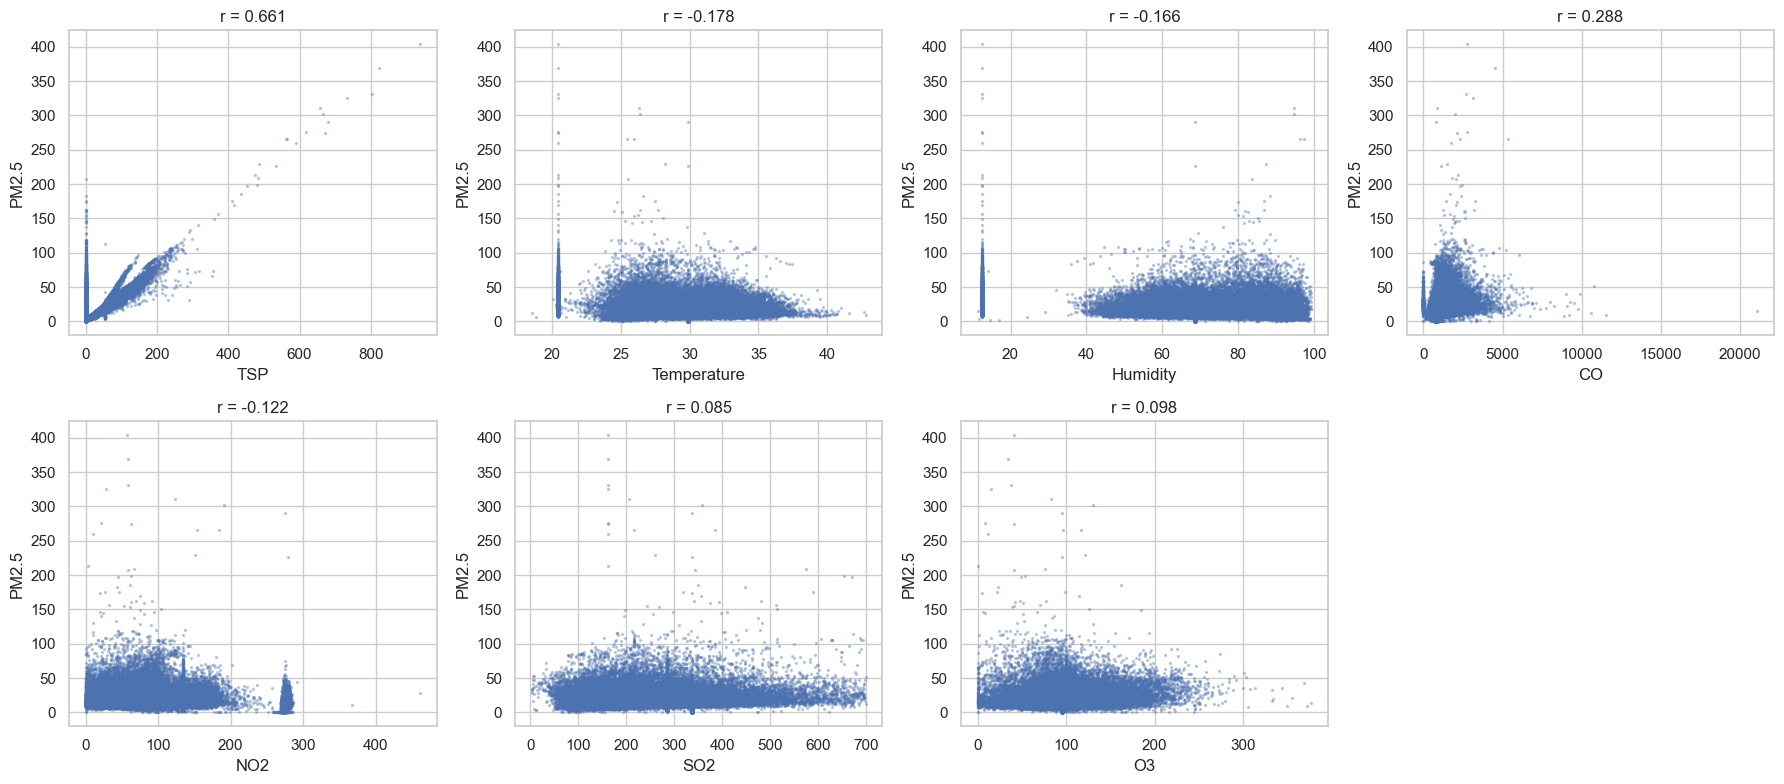

In [8]:
features = ['TSP','Temperature','Humidity','CO','NO2','SO2','O3']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, f in zip(axes.flatten(), features):
    ax.scatter(df[f], df['PM2.5'], s=2, alpha=0.3)
    ax.set_xlabel(f); ax.set_ylabel('PM2.5')
    r = df[[f,'PM2.5']].corr().iloc[0,1]
    ax.set_title(f'r = {r:.3f}')
axes.flatten()[-1].axis('off')
plt.tight_layout(); plt.show()

## 2.6 Ma trận tương quan

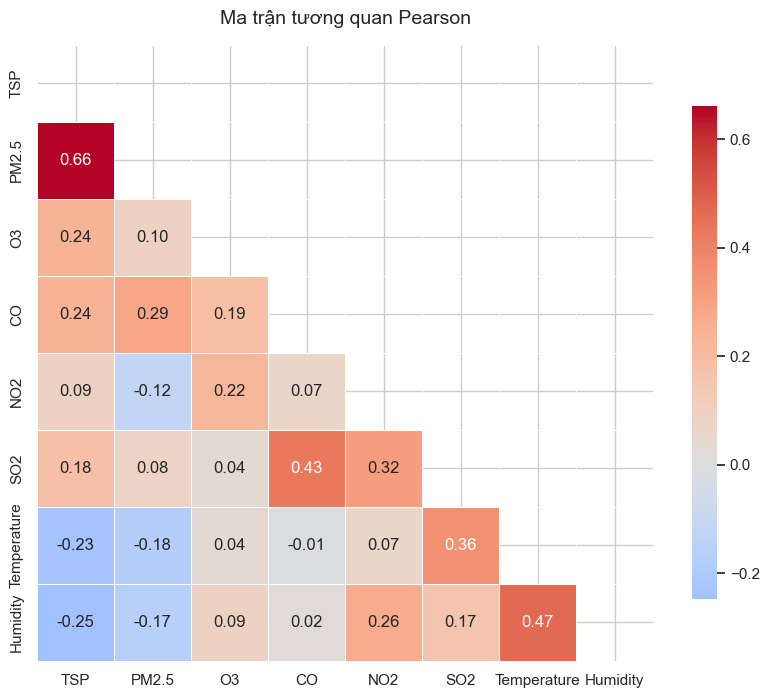

In [ ]:
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, 
    mask=mask,          
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    center=0,
    square=True,        
    linewidths=.5,     
    cbar_kws={"shrink": .8}
)
plt.title('Ma trận tương quan Pearson', fontsize=14, pad=15)
plt.show()


TSP có tương quan dương rất mạnh với PM2.5 (r = 0.66). CO có tương
quan dương trung bình (r = 0.28). Nhiệt độ và độ ẩm có tương quan âm
nhẹ với PM2.5.

## 2.7 Biến động theo thời gian

### 2.7.1 PM2.5 theo ngày tại các trạm

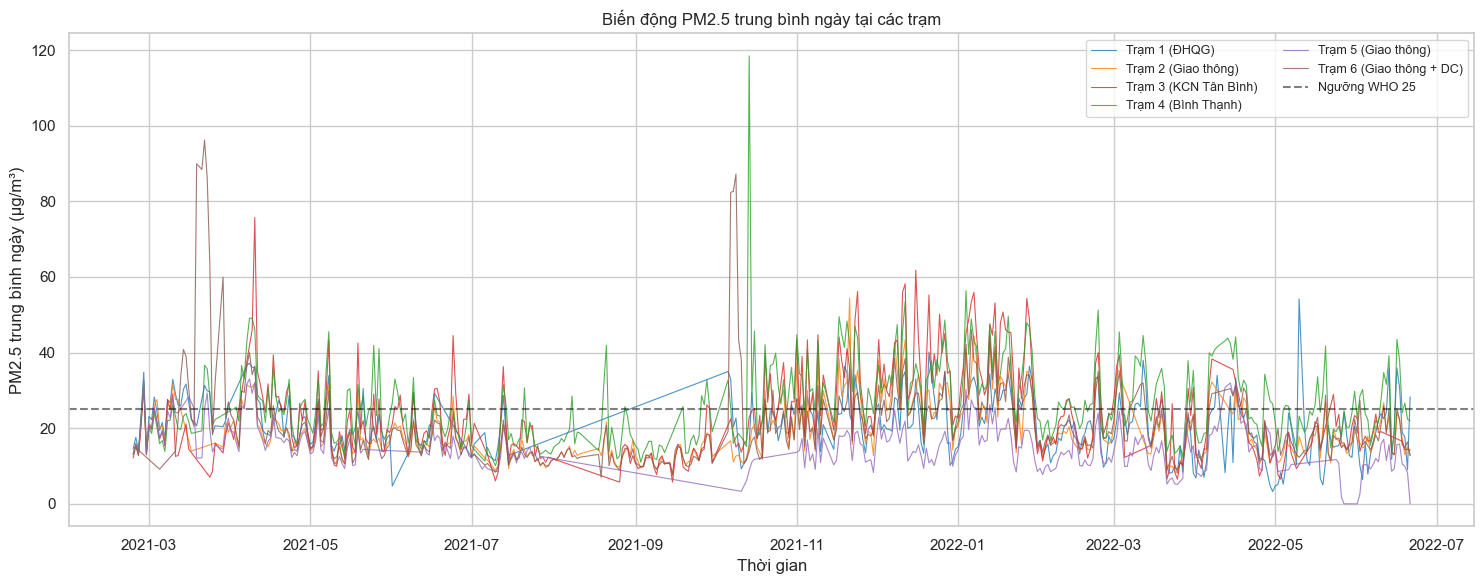

In [10]:
df['date_only'] = df['date'].dt.date
daily = df.groupby(['date_only','Station_No'])['PM2.5'].mean().reset_index()
daily['date_only'] = pd.to_datetime(daily['date_only'])

fig, ax = plt.subplots(figsize=(15,6))
station_colors = {1:'tab:blue', 2:'tab:orange', 3:'tab:red',
                  4:'tab:green', 5:'tab:purple', 6:'tab:brown'}
station_names = {1:'Trạm 1 (ĐHQG)', 2:'Trạm 2 (Giao thông)',
                 3:'Trạm 3 (KCN Tân Bình)', 4:'Trạm 4 (Bình Thạnh)',
                 5:'Trạm 5 (Giao thông)', 6:'Trạm 6 (Giao thông + DC)'}
for s in sorted(daily['Station_No'].unique()):
    sub = daily[daily['Station_No']==s].sort_values('date_only')
    ax.plot(sub['date_only'], sub['PM2.5'], lw=0.8, alpha=0.8,
            color=station_colors[s], label=station_names[s])
ax.axhline(25, color='black', linestyle='--', alpha=0.5, label='Ngưỡng WHO 25')
ax.set_xlabel('Thời gian'); ax.set_ylabel('PM2.5 trung bình ngày (µg/m³)')
ax.set_title('Biến động PM2.5 trung bình ngày tại các trạm')
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

Trạm 3 (KCN Tân Bình) có nồng độ cao vượt trội so với các trạm khác
trong gần như toàn bộ thời kỳ. Tất cả các trạm đều có pattern mùa rõ
rệt: PM2.5 cao vào mùa khô (11-4), thấp hơn vào mùa mưa (5-10).

### 2.7.2 PM2.5 theo giờ trong ngày

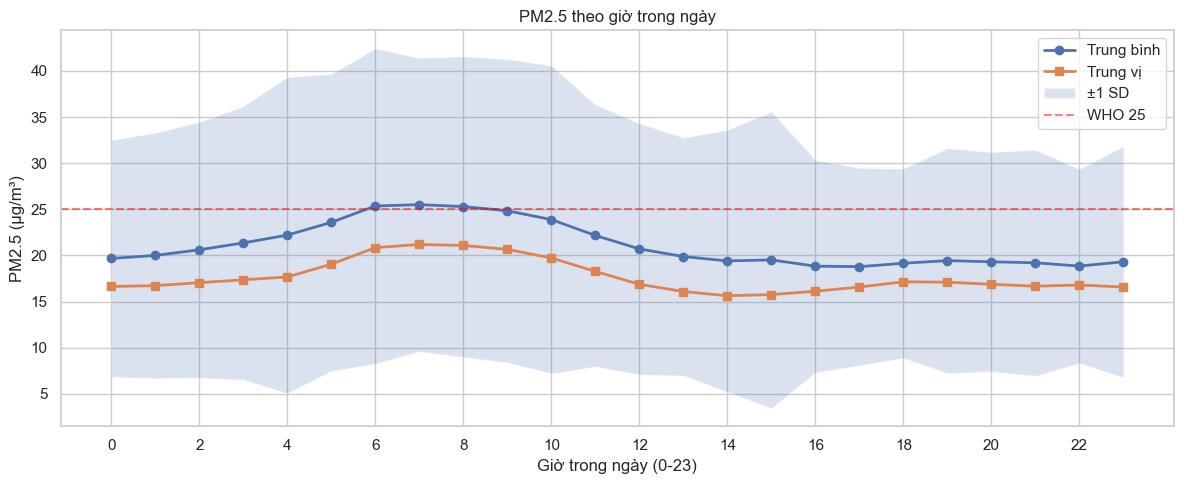

hour_group
morning_rush   25.2500
night          21.2500
daytime        20.9400
evening        19.1700
evening_rush   19.0600
Name: PM2.5, dtype: float64


In [11]:
hourly = df.groupby('hour')['PM2.5'].agg(['mean','median','std']).reset_index()

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(hourly['hour'], hourly['mean'], marker='o', lw=2, label='Trung bình')
ax.plot(hourly['hour'], hourly['median'], marker='s', lw=2, label='Trung vị')
ax.fill_between(hourly['hour'],
                 hourly['mean']-hourly['std'], hourly['mean']+hourly['std'],
                 alpha=0.2, label='±1 SD')
ax.axhline(25, color='red', linestyle='--', alpha=0.5, label='WHO 25')
ax.set_xlabel('Giờ trong ngày (0-23)')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('PM2.5 theo giờ trong ngày')
ax.set_xticks(range(0,24,2))
ax.legend()
plt.tight_layout(); plt.show()

print(df.groupby('hour_group')['PM2.5'].mean().round(2).sort_values(ascending=False))

PM2.5 đạt đỉnh vào ban đêm và sáng sớm (0-7h), thấp nhất vào ban trưa
(12-15h). Ban đêm khí quyển ổn định, ít đối lưu nên bụi tích tụ ở tầng
thấp. Ban trưa nhiệt độ cao thúc đẩy đối lưu, bụi khuếch tán lên cao.

### 2.7.3 PM2.5 theo ngày trong tuần

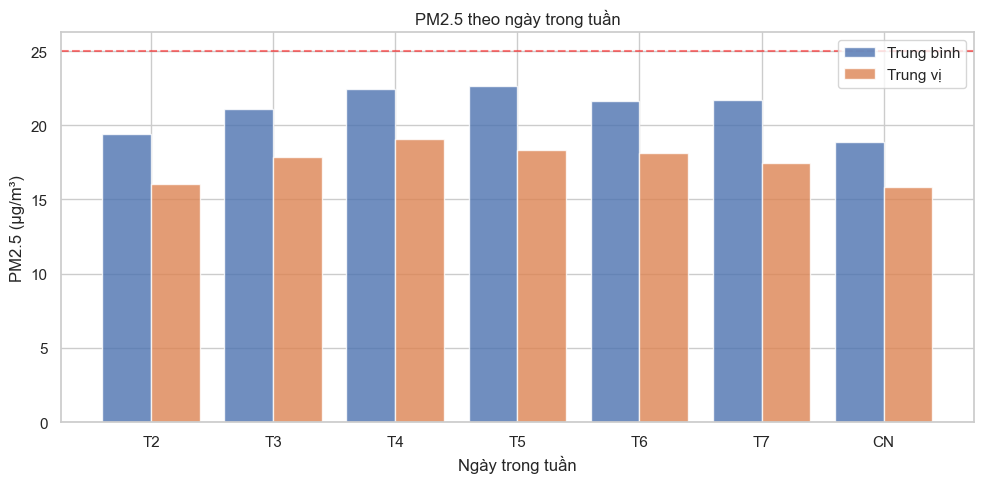

PM2.5 TB ngày thường (T2-T6): 21.44
PM2.5 TB cuối tuần (T7-CN) : 20.31


In [12]:
day_names = ['T2','T3','T4','T5','T6','T7','CN']
dow_stats = df.groupby('dow')['PM2.5'].agg(['mean','median']).reset_index()

fig, ax = plt.subplots(figsize=(10,5))
x = dow_stats['dow']
ax.bar(x-0.2, dow_stats['mean'], width=0.4, label='Trung bình', alpha=0.8)
ax.bar(x+0.2, dow_stats['median'], width=0.4, label='Trung vị', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(day_names)
ax.set_xlabel('Ngày trong tuần')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('PM2.5 theo ngày trong tuần')
ax.legend()
ax.axhline(25, color='red', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

print(f"PM2.5 TB ngày thường (T2-T6): {df[df['dow']<5]['PM2.5'].mean():.2f}")
print(f"PM2.5 TB cuối tuần (T7-CN) : {df[df['dow']>=5]['PM2.5'].mean():.2f}")

Mức PM2.5 khá đồng đều giữa các ngày trong tuần. Nguồn phát thải chủ
yếu là hoạt động cố định (công nghiệp, sinh hoạt) hơn là giao thông
biến đổi theo tuần.

### 2.7.4 PM2.5 theo tháng

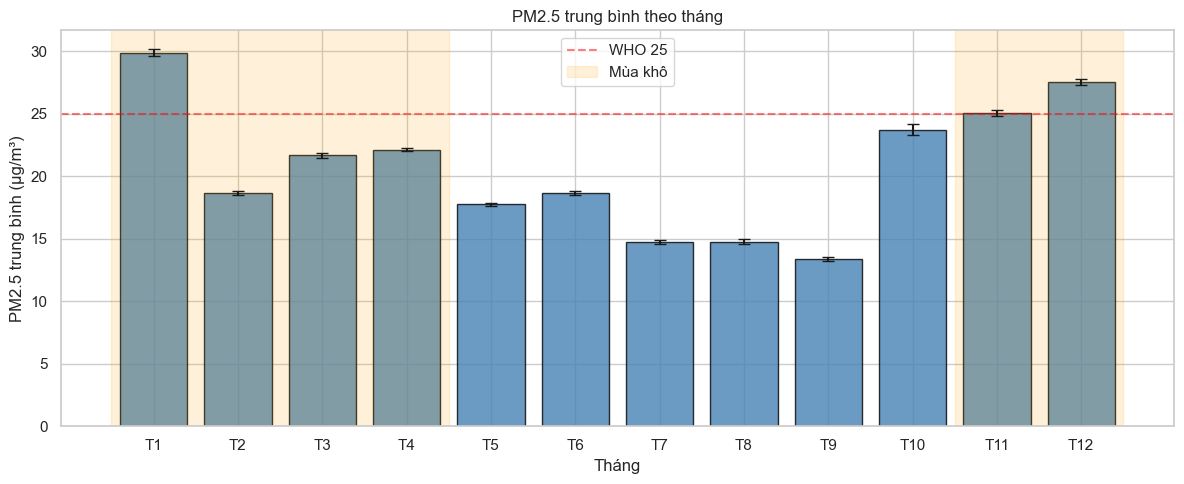

PM2.5 TB mùa khô (T11-T4): 23.85
PM2.5 TB mùa mưa (T5-T10): 17.68


In [13]:
month_stats = df.groupby('month')['PM2.5'].agg(['mean','std','count']).reset_index()
month_names = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']

fig, ax = plt.subplots(figsize=(12,5))
yerr = (month_stats['std'] / np.sqrt(month_stats['count'])).values
ax.bar(month_stats['month'], month_stats['mean'].values,
       yerr=yerr, capsize=4, alpha=0.8, color='steelblue', edgecolor='black')
ax.axhline(25, color='red', linestyle='--', alpha=0.5, label='WHO 25')
ax.axvspan(10.5, 12.5, alpha=0.15, color='orange', label='Mùa khô')
ax.axvspan(0.5, 4.5, alpha=0.15, color='orange')
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names)
ax.set_xlabel('Tháng')
ax.set_ylabel('PM2.5 trung bình (µg/m³)')
ax.set_title('PM2.5 trung bình theo tháng')
ax.legend()
plt.tight_layout(); plt.show()

print(f"PM2.5 TB mùa khô (T11-T4): {df[df['is_dry_season']==1]['PM2.5'].mean():.2f}")
print(f"PM2.5 TB mùa mưa (T5-T10): {df[df['is_dry_season']==0]['PM2.5'].mean():.2f}")

Mùa khô (T11-T4) có PM2.5 cao hơn mùa mưa khoảng 6 µg/m³. Mưa rửa bụi
khỏi không khí; độ ẩm cao mùa mưa làm bụi ngưng tụ và lắng xuống.

# Chương 3. Hồi quy tuyến tính

Chương này trả lời câu hỏi yếu tố nào ảnh hưởng đến PM2.5. Quy trình:

1. Mã hoá biến chỉ số (Station, hour_group)
2. Temporal split theo từng trạm
3. Mô hình đầy đủ + kiểm định
4. So sánh M1/M2/M3/M4 bằng AIC/BIC/Cp/PRESS
5. Stepwise selection
6. Chẩn đoán phần dư
7. Biến đổi Box-Cox
8. So sánh có vs không TSP
9. Phân tích yếu tố ảnh hưởng (standardized coefficients)

## 3.1 Mã hoá biến chỉ số

In [14]:
df_model = pd.get_dummies(df, columns=['Station_No','hour_group'],
                          prefix=['S','H'], drop_first=True, dtype=int)
station_dummies = [c for c in df_model.columns if c.startswith('S_')]
hour_dummies = [c for c in df_model.columns if c.startswith('H_')]

print('Biến chỉ số trạm:', station_dummies)
print('Biến chỉ số giờ:', hour_dummies)

Biến chỉ số trạm: ['S_2', 'S_3', 'S_4', 'S_5', 'S_6']
Biến chỉ số giờ: ['H_evening', 'H_evening_rush', 'H_morning_rush', 'H_night']


## 3.2 Temporal split

Dữ liệu là chuỗi thời gian. Random split sẽ trộn quan sát train và test
xen kẽ theo thời gian, gây leakage. Ta sắp xếp theo thời gian rồi lấy
80% đầu làm train, 20% cuối làm test, thực hiện trong từng trạm để cân
bằng giữa các trạm.

In [15]:
df_sorted = df.sort_values(['Station_No','date']).reset_index()
train_indices, test_indices = [], []
for station in sorted(df_sorted['Station_No'].unique()):
    mask = df_sorted['Station_No'] == station
    n = mask.sum()
    n_train = int(0.8 * n)
    idx_sorted = df_sorted.index[mask].tolist()
    train_indices.extend(df_sorted.loc[idx_sorted[:n_train], 'index'].tolist())
    test_indices.extend(df_sorted.loc[idx_sorted[n_train:], 'index'].tolist())

train_df = df_model.loc[train_indices].reset_index(drop=True)
test_df = df_model.loc[test_indices].reset_index(drop=True)

print(f'Train: {len(train_df):,} quan sát')
print(f'Test : {len(test_df):,} quan sát')
print(f'Khoảng thời gian train: {df.loc[train_indices, "date"].min()} → {df.loc[train_indices, "date"].max()}')
print(f'Khoảng thời gian test : {df.loc[test_indices, "date"].min()} → {df.loc[test_indices, "date"].max()}')

Train: 42,035 quan sát
Test : 10,513 quan sát
Khoảng thời gian train: 2021-02-23 21:00:00 → 2022-04-07 11:00:00
Khoảng thời gian test : 2022-03-01 08:00:00 → 2022-06-21 17:00:00


## 3.3 Mô hình đầy đủ

In [16]:
quant = ['TSP','O3','CO','NO2','SO2','Temperature','Humidity']
time_feat = ['is_weekend','is_dry_season']
all_features = quant + station_dummies + hour_dummies + time_feat

X_train = train_df[all_features]
y_train = train_df['PM2.5']
X_test = test_df[all_features]
y_test = test_df['PM2.5']

X_train_sm = sm.add_constant(X_train).astype(float)
ols_full = sm.OLS(y_train, X_train_sm).fit()
print(ols_full.summary())

                            OLS Regression Results                            
Dep. Variable:                  PM2.5   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     4884.
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        22:53:14   Log-Likelihood:            -1.4865e+05
No. Observations:               42035   AIC:                         2.973e+05
Df Residuals:                   42016   BIC:                         2.975e+05
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.2496      0.565      2.

## 3.4 Kiểm định đa cộng tuyến (VIF)

In [17]:
vif_df = pd.DataFrame({
    'Feature': X_train_sm.columns,
    'VIF': [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
})
print(vif_df.round(3))
print('\nNgưỡng: VIF > 5 đáng lưu ý; > 10 nghiêm trọng.')

           Feature      VIF
0            const 194.4430
1              TSP   1.8580
2               O3   1.5510
3               CO   1.8800
4              NO2   2.3310
5              SO2   2.2200
6      Temperature   2.8420
7         Humidity   3.4800
8              S_2   2.3390
9              S_3   2.7560
10             S_4   4.9160
11             S_5   2.0780
12             S_6   2.3070
13       H_evening   1.8470
14  H_evening_rush   1.6790
15  H_morning_rush   1.8190
16         H_night   2.4710
17      is_weekend   1.0060
18   is_dry_season   1.2510

Ngưỡng: VIF > 5 đáng lưu ý; > 10 nghiêm trọng.


## 3.5 So sánh các mô hình ứng cử

Bốn mô hình có độ phức tạp tăng dần:
- M1: chỉ biến hoá học (TSP, CO, NO2, SO2, O3)
- M2: + khí tượng (Temperature, Humidity)
- M3: + vị trí (5 biến chỉ số trạm)
- M4: + thời gian (4 biến chỉ số giờ, weekend, dry_season)

In [18]:
def fit_and_compute(X, y, name):
    Xs = sm.add_constant(X).astype(float)
    m = sm.OLS(y, Xs).fit()
    Q, _ = np.linalg.qr(Xs.values)
    h = (Q**2).sum(axis=1)
    e = m.resid.values
    press = float(np.sum((e / (1 - h))**2))
    return {
        'Model': name,
        'p': int(len(m.params)),
        'R²': m.rsquared,
        'R²_Adj': m.rsquared_adj,
        'MSRes': m.mse_resid,
        'AIC': m.aic,
        'BIC': m.bic,
        'PRESS': press,
        'SSRes': float(np.sum(m.resid**2))
    }

results = []
results.append(fit_and_compute(X_train[['TSP','O3','CO','NO2','SO2']], y_train, 'M1: Hoá học'))
results.append(fit_and_compute(X_train[quant], y_train, 'M2: + Khí tượng'))
results.append(fit_and_compute(X_train[quant + station_dummies], y_train, 'M3: + Vị trí'))
results.append(fit_and_compute(X_train, y_train, 'M4: + Thời gian (full)'))

sigma2_full = results[-1]['MSRes']
n_train = len(X_train)
for r in results:
    r['Cp'] = r['SSRes']/sigma2_full - n_train + 2*r['p']

comp = pd.DataFrame(results)[['Model','p','R²','R²_Adj','MSRes','Cp','AIC','BIC','PRESS']]
print(comp.to_string(index=False))

                 Model  p     R²  R²_Adj    MSRes         Cp         AIC         BIC        PRESS
           M1: Hoá học  6 0.4719  0.4718 112.7857 26587.7030 317932.1088 317983.9864 4746685.1104
       M2: + Khí tượng  8 0.4762  0.4761 111.8797 26037.3441 317595.0961 317664.2662 4708851.9467
          M3: + Vị trí 13 0.6717  0.6716  70.1222   641.1843 297961.9574 298074.3588 2950101.8233
M4: + Thời gian (full) 19 0.6766  0.6765  69.0894    19.0000 297344.2271 297508.5060 2907424.5461


Thêm vị trí (M2 → M3) cải thiện R² đáng kể nhất. M4 là tốt nhất ở mọi
tiêu chí và được chọn làm cơ sở cho các phân tích tiếp theo.

## 3.6 Stepwise selection

Tài liệu (Mục 3.4.2) trình bày stepwise như phương pháp chính thống.
Harrell (2001) và Steyerberg (2009) đã phê bình stepwise có thể gây
p-value inflation và overfitting nên ta kết hợp với AIC/BIC và test set.

In [19]:
def stepwise_selection(X, y, threshold_in=0.05, threshold_out=0.10, verbose=True):
    included = []
    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        if excluded:
            new_pval = pd.Series(index=excluded, dtype=float)
            for col in excluded:
                m = sm.OLS(y, sm.add_constant(X[included+[col]]).astype(float)).fit()
                new_pval[col] = m.pvalues[col]
            if new_pval.min() < threshold_in:
                best = new_pval.idxmin()
                included.append(best); changed = True
                if verbose: print(f'  + {best} (p={new_pval.min():.4g})')
        if included:
            m = sm.OLS(y, sm.add_constant(X[included]).astype(float)).fit()
            pvals = m.pvalues.iloc[1:]
            if pvals.max() > threshold_out:
                worst = pvals.idxmax(); included.remove(worst); changed = True
                if verbose: print(f'  - {worst} (p={pvals.max():.4g})')
        if not changed: break
    return included

selected = stepwise_selection(X_train, y_train)
print(f'\nBiến được chọn ({len(selected)}/{len(X_train.columns)}):')
print(selected)

  + is_dry_season (p=0)
  + S_5 (p=0)
  + TSP (p=0)
  + NO2 (p=0)
  + S_3 (p=0)
  + CO (p=1.235e-215)
  + H_night (p=7.517e-51)
  + H_morning_rush (p=1.735e-20)
  + Temperature (p=6.837e-15)
  + S_2 (p=2.563e-19)
  + S_6 (p=1.584e-23)
  + S_4 (p=6.127e-08)
  + Humidity (p=1.429e-12)
  + H_evening_rush (p=0.0001436)
  + O3 (p=0.0002778)
  + SO2 (p=0.001735)

Biến được chọn (16/18):
['is_dry_season', 'S_5', 'TSP', 'NO2', 'S_3', 'CO', 'H_night', 'H_morning_rush', 'Temperature', 'S_2', 'S_6', 'S_4', 'Humidity', 'H_evening_rush', 'O3', 'SO2']


## 3.7 Mô hình cuối

In [20]:
X_train_final = sm.add_constant(X_train[selected]).astype(float)
ols_final = sm.OLS(y_train, X_train_final).fit()
print(ols_final.summary())

                            OLS Regression Results                            
Dep. Variable:                  PM2.5   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     5494.
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        22:53:18   Log-Likelihood:            -1.4865e+05
No. Observations:               42035   AIC:                         2.973e+05
Df Residuals:                   42018   BIC:                         2.975e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.0429      0.541      1.

## 3.8 Chẩn đoán phần dư

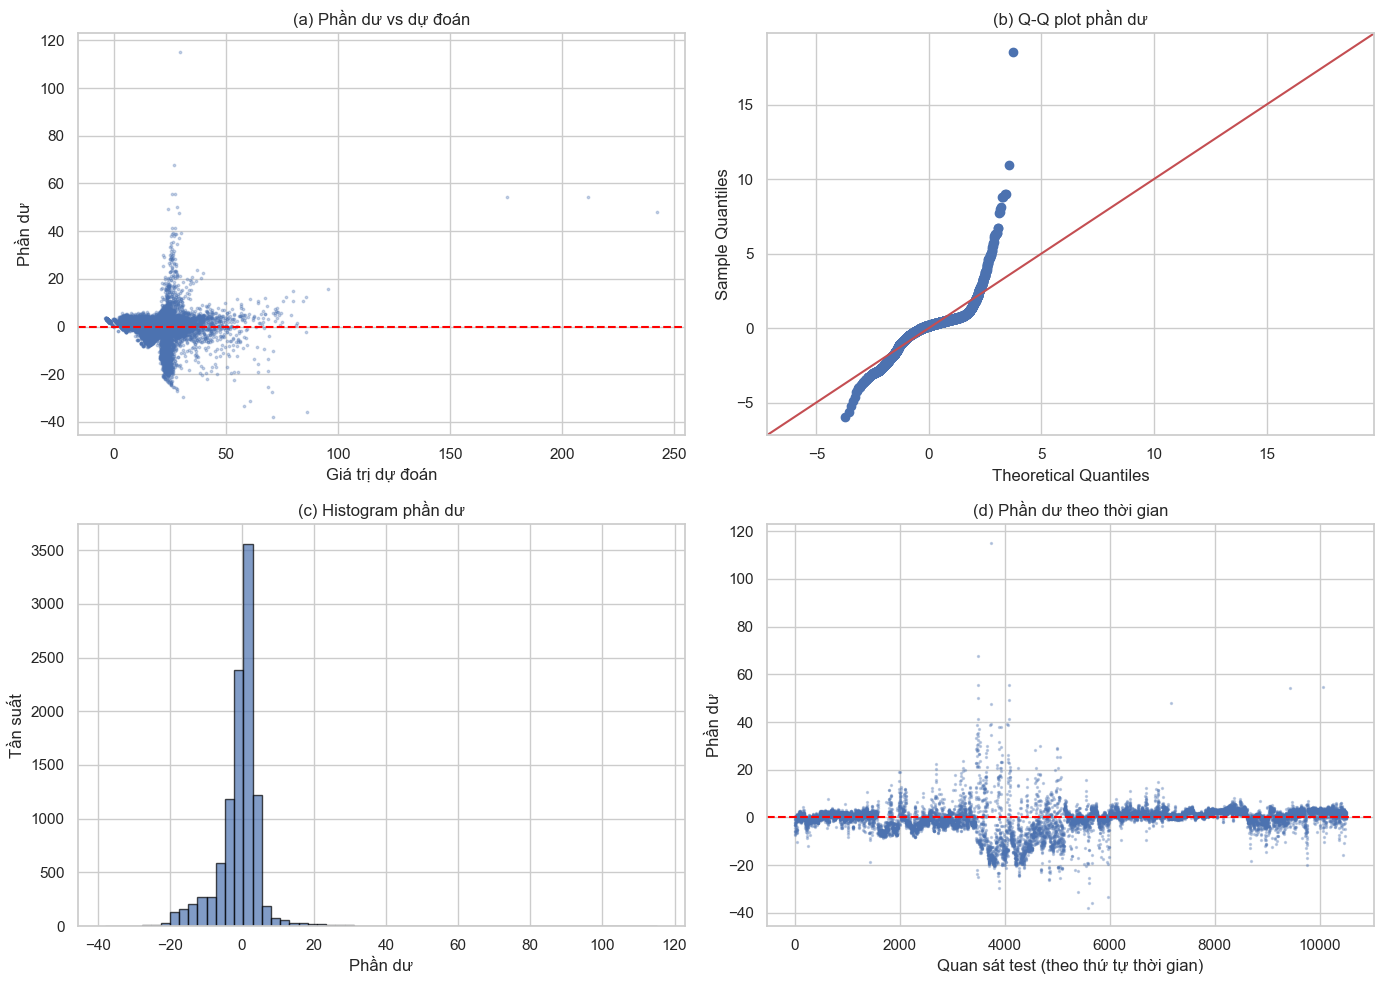

Breusch-Pagan: LM = 3429.31, p = 0
Jarque-Bera : JB = 3836867.45, p = 0
  Skewness = 4.109, Kurtosis = 49.078


In [21]:
X_test_final = sm.add_constant(X_test[selected]).astype(float)
y_pred = ols_final.predict(X_test_final)
resid = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(y_pred, resid, s=3, alpha=0.3)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel('Giá trị dự đoán'); axes[0,0].set_ylabel('Phần dư')
axes[0,0].set_title('(a) Phần dư vs dự đoán')

sm.qqplot(resid, line='45', fit=True, ax=axes[0,1])
axes[0,1].set_title('(b) Q-Q plot phần dư')

axes[1,0].hist(resid, bins=60, edgecolor='black', alpha=0.7)
axes[1,0].set_xlabel('Phần dư'); axes[1,0].set_ylabel('Tần suất')
axes[1,0].set_title('(c) Histogram phần dư')

axes[1,1].scatter(range(len(resid)), resid, s=2, alpha=0.3)
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_xlabel('Quan sát test (theo thứ tự thời gian)')
axes[1,1].set_ylabel('Phần dư')
axes[1,1].set_title('(d) Phần dư theo thời gian')

plt.tight_layout(); plt.show()

bp = het_breuschpagan(ols_final.resid, X_train_final.values)
jb = jarque_bera(ols_final.resid)
print(f'Breusch-Pagan: LM = {bp[0]:.2f}, p = {bp[1]:.4g}')
print(f'Jarque-Bera : JB = {jb[0]:.2f}, p = {jb[1]:.4g}')
print(f'  Skewness = {jb[2]:.3f}, Kurtosis = {jb[3]:.3f}')

Phần dư có heteroscedasticity (BP bác bỏ H0) và không chuẩn (skew và
kurt cách xa 0, 3). Đây là vi phạm thường gặp ở dữ liệu môi trường. Với
cỡ mẫu rất lớn (n > 42.000), các ước lượng vẫn nhất quán theo định lý
giới hạn trung tâm.

## 3.9 Biến đổi Box-Cox

Khi phần dư vi phạm giả định chuẩn, có thể thử biến đổi biến phản hồi.
Phương pháp Box-Cox tự động tìm λ tối ưu.

λ tối ưu (MLE): -0.2368
Box-Cox với λ = -0.237


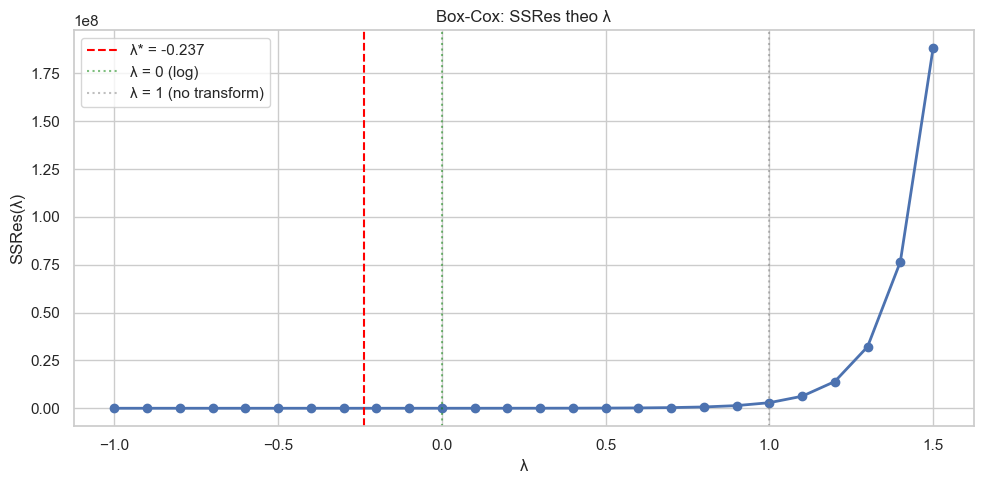

In [22]:
y_train_pos = y_train + 1
lambda_opt = boxcox_normmax(y_train_pos, method='mle')
print(f'λ tối ưu (MLE): {lambda_opt:.4f}')

if abs(lambda_opt) < 0.1:
    print('λ gần 0: gợi ý biến đổi log')
elif abs(lambda_opt - 0.5) < 0.1:
    print('λ gần 0.5: gợi ý biến đổi sqrt')
else:
    print(f'Box-Cox với λ = {lambda_opt:.3f}')

lambdas = np.linspace(-1, 1.5, 26)
ssres = []
for lam in lambdas:
    if abs(lam) < 1e-6:
        y_trans = np.log(y_train_pos)
    else:
        y_trans = (y_train_pos**lam - 1) / lam
    m_tmp = sm.OLS(y_trans, X_train_final).fit()
    ssres.append(np.sum(m_tmp.resid**2))

plt.figure(figsize=(10,5))
plt.plot(lambdas, ssres, marker='o', lw=2)
plt.axvline(lambda_opt, color='red', linestyle='--', label=f'λ* = {lambda_opt:.3f}')
plt.axvline(0, color='green', linestyle=':', alpha=0.5, label='λ = 0 (log)')
plt.axvline(1, color='gray', linestyle=':', alpha=0.5, label='λ = 1 (no transform)')
plt.xlabel('λ'); plt.ylabel('SSRes(λ)')
plt.title('Box-Cox: SSRes theo λ')
plt.legend(); plt.tight_layout(); plt.show()

## 3.10 So sánh có TSP vs không TSP

TSP là tổng các hạt bụi lơ lửng; về vật lý, TSP bao gồm PM2.5. Đưa TSP
vào mô hình giải thích PM2.5 sẽ cho R² cao nhưng phần nào là "tự giải
thích". Ta xây 2 mô hình:
- Mô hình A (có TSP): mối quan hệ thống kê đầy đủ
- Mô hình B (không TSP): chỉ dùng yếu tố ngoại sinh (khí tượng, vị trí,
  thời gian, các chất ô nhiễm khác)

In [23]:
results_tsp = []
for name, feats in [
    ('CÓ TSP', selected),
    ('KHÔNG TSP', [f for f in selected if f != 'TSP'])
]:
    X_tr = sm.add_constant(X_train[feats]).astype(float)
    X_te = sm.add_constant(X_test[feats]).astype(float)
    m = sm.OLS(y_train, X_tr).fit()
    yp = m.predict(X_te)
    ss_res = np.sum((y_test - yp)**2)
    ss_tot = np.sum((y_test - y_test.mean())**2)
    r2_test = 1 - ss_res/ss_tot
    rmse = np.sqrt(np.mean((y_test - yp)**2))
    mae = np.mean(np.abs(y_test - yp))
    results_tsp.append({
        'Mô hình': name,
        'R²_train': m.rsquared,
        'R²_Adj': m.rsquared_adj,
        'AIC': m.aic,
        'R²_test': r2_test,
        'RMSE_test': rmse,
        'MAE_test': mae
    })

df_tsp = pd.DataFrame(results_tsp)
print(df_tsp.round(4).to_string(index=False))

  Mô hình  R²_train  R²_Adj         AIC  R²_test  RMSE_test  MAE_test
   CÓ TSP    0.6766  0.6764 297343.8866   0.7341     6.2782    3.8383
KHÔNG TSP    0.2486  0.2483 332776.4700   0.1251    11.3889    8.1053


Bỏ TSP làm R² test rớt từ 0.73 xuống 0.13, RMSE tăng gần gấp đôi. Như
vậy TSP chứa thông tin chủ đạo về PM2.5 do quan hệ vật lý "bao gồm".
Khi chỉ dùng yếu tố ngoại sinh (loại trừ TSP), mô hình giải thích được
khoảng 25% biến thiên — phản ánh khả năng dự báo trong tình huống
không có thông tin về bụi tổng.

## 3.11 Phân tích yếu tố ảnh hưởng đến PM2.5

Phần này trả lời câu hỏi nghiên cứu chính. Quy trình:
1. Tính standardized coefficients
2. Xếp hạng các yếu tố
3. Phân tích đóng góp theo nhóm

### 3.11.1 Standardized coefficients

Hệ số gốc β có đơn vị khác nhau giữa các biến nên không so sánh trực
tiếp được. Standardized coefficient β_std = β × σ_x / σ_y cho biết số
độ lệch chuẩn y thay đổi khi x tăng 1 độ lệch chuẩn.

In [24]:
sd_y = y_train.std()
rows = []
for col in ols_final.params.index:
    if col == 'const': continue
    if col in X_train.columns:
        sd_x = X_train[col].std()
        beta_std = ols_final.params[col] * sd_x / sd_y
        rows.append({
            'Biến': col,
            'β_raw': ols_final.params[col],
            'β_std': beta_std,
            '|β_std|': abs(beta_std),
            't-stat': ols_final.tvalues[col],
            'p-value': ols_final.pvalues[col]
        })

df_imp = pd.DataFrame(rows).sort_values('|β_std|', ascending=False).reset_index(drop=True)
df_imp.insert(0, 'Hạng', range(1, len(df_imp)+1))
print(df_imp.round(4).to_string(index=False))

 Hạng           Biến   β_raw   β_std  |β_std|   t-stat  p-value
    1            TSP  0.3582  0.8889   0.8889 235.7995   0.0000
    2            S_3 22.8585  0.5738   0.5738 124.6924   0.0000
    3            NO2 -0.0254 -0.1158   0.1158 -27.5865   0.0000
    4             CO  0.0022  0.0830   0.0830  21.8267   0.0000
    5  is_dry_season  1.9318  0.0650   0.0650  20.9518   0.0000
    6            S_5  2.6801  0.0639   0.0639  15.9835   0.0000
    7            S_4  2.1125  0.0566   0.0566   9.2588   0.0000
    8            S_2  2.0087  0.0526   0.0526  12.4500   0.0000
    9            S_6  1.9295  0.0508   0.0508  12.0766   0.0000
   10    Temperature -0.1366 -0.0376   0.0376  -8.5964   0.0000
   11       Humidity  0.0218  0.0358   0.0358   7.2540   0.0000
   12        H_night  1.0098  0.0299   0.0299   8.5675   0.0000
   13 H_morning_rush  0.7618  0.0194   0.0194   6.0602   0.0000
   14 H_evening_rush -0.5749 -0.0147   0.0147  -4.6754   0.0000
   15             O3  0.0061  0.0146   0

### 3.11.2 Biểu đồ xếp hạng

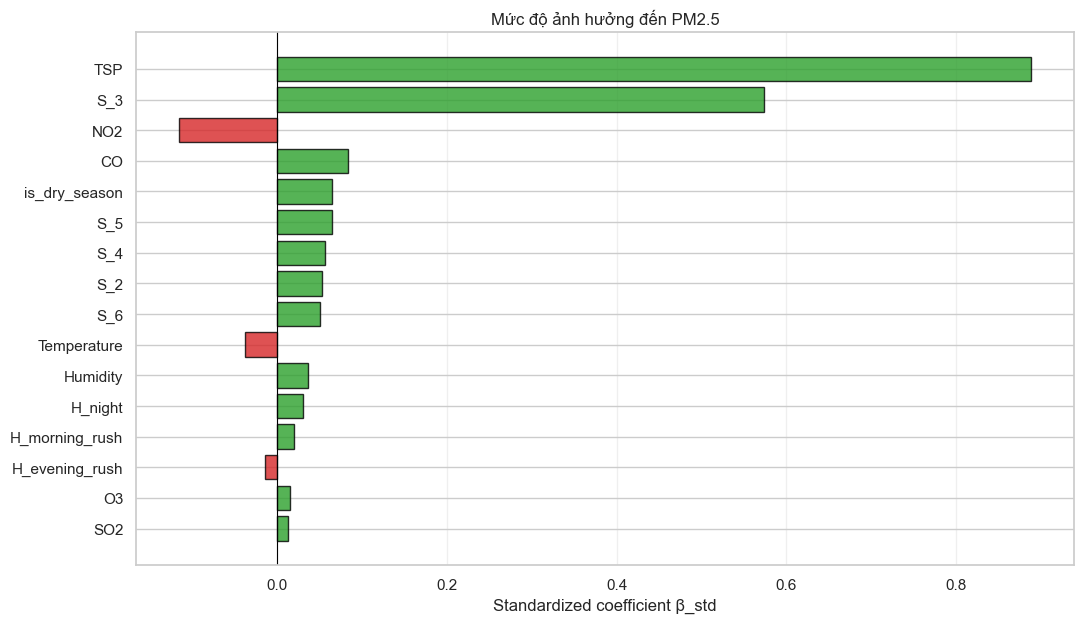

In [25]:
fig, ax = plt.subplots(figsize=(11, max(6, len(df_imp)*0.4)))
colors = ['tab:red' if x < 0 else 'tab:green' for x in df_imp['β_std']]
ax.barh(df_imp['Biến'][::-1], df_imp['β_std'][::-1], color=colors[::-1],
        edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized coefficient β_std')
ax.set_title('Mức độ ảnh hưởng đến PM2.5')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

### 3.11.3 Phân tích theo nhóm

                                     Nhóm  Số biến  Số biến có ý nghĩa  Σ|β_std|  % tổng
Chất ô nhiễm khác (TSP, CO, NO2, SO2, O3)        5                   5    1.1150 52.7230
                   Vị trí địa lý (5 trạm)        5                   5    0.7980 37.7120
              Khí tượng (Nhiệt độ, Độ ẩm)        2                   2    0.0730  3.4680
                              Mùa và tuần        2                   1    0.0650  3.0720
                           Giờ trong ngày        4                   3    0.0640  3.0260


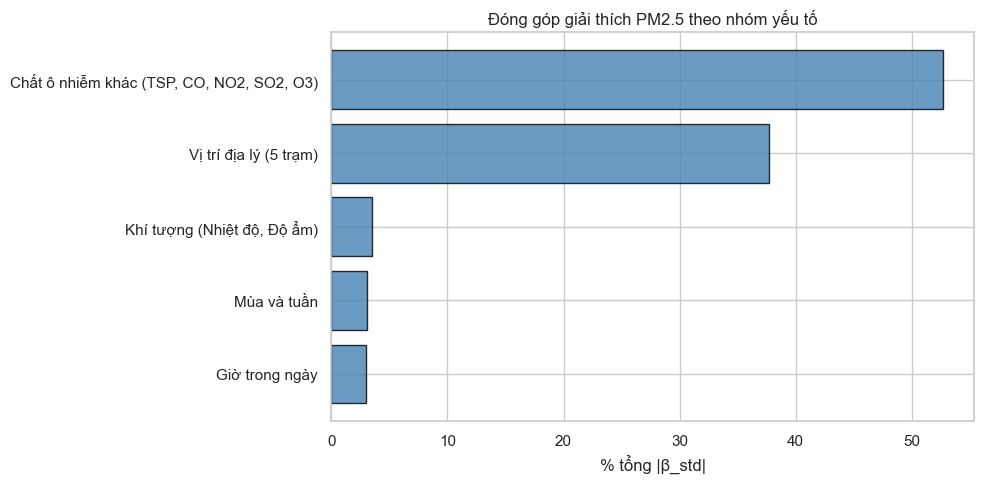

In [26]:
groups = {
    'Chất ô nhiễm khác (TSP, CO, NO2, SO2, O3)': ['TSP','O3','CO','NO2','SO2'],
    'Khí tượng (Nhiệt độ, Độ ẩm)': ['Temperature','Humidity'],
    'Vị trí địa lý (5 trạm)': station_dummies,
    'Giờ trong ngày': hour_dummies,
    'Mùa và tuần': time_feat
}

group_imp = []
for name, cols in groups.items():
    relevant = df_imp[df_imp['Biến'].isin(cols)]
    if len(relevant) > 0:
        sum_abs = relevant['|β_std|'].sum()
        n_sig = (relevant['p-value'] < 0.05).sum()
        group_imp.append({
            'Nhóm': name,
            'Số biến': len(cols),
            'Số biến có ý nghĩa': n_sig,
            'Σ|β_std|': sum_abs,
        })

df_grp = pd.DataFrame(group_imp)
total = df_grp['Σ|β_std|'].sum()
df_grp['% tổng'] = (df_grp['Σ|β_std|'] / total * 100)
df_grp = df_grp.sort_values('Σ|β_std|', ascending=False).reset_index(drop=True)
print(df_grp.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10,5))
ax.barh(df_grp['Nhóm'][::-1], df_grp['% tổng'][::-1],
        color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('% tổng |β_std|')
ax.set_title('Đóng góp giải thích PM2.5 theo nhóm yếu tố')
plt.tight_layout(); plt.show()

### 3.11.4 Diễn giải

Thứ tự tác động đến PM2.5:

1. TSP là yếu tố ảnh hưởng mạnh nhất (β_std ≈ 0.89). Phần lớn là tương
   quan vật lý vì PM2.5 là tập con của TSP.
2. Khu công nghiệp Tân Bình (S_3) là yếu tố không gian quan trọng nhất
   (β_std ≈ 0.57). Vùng KCN cao hơn các vùng khác 22-23 µg/m³ ở cùng
   điều kiện khí tượng.
3. Các chất ô nhiễm CO và NO2 có tác động vừa phải. NO2 có hệ số âm
   sau khi kiểm soát các biến khác — hiệu ứng đối thủ giữa các nguồn
   phát thải.
4. Mùa khô có ảnh hưởng dương đáng kể (β_std ≈ 0.07): cùng điều kiện
   khác, PM2.5 mùa khô cao hơn mùa mưa khoảng 2 µg/m³.
5. Khí tượng và giờ trong ngày có tác động nhỏ hơn dự đoán ban đầu khi
   kiểm soát các biến khác.

Câu trả lời cho RQ: yếu tố ảnh hưởng đến PM2.5 chủ yếu là (i) các chất
ô nhiễm cùng nguồn phát thải, (ii) vị trí địa lý (đặc biệt KCN), và
(iii) yếu tố mùa. Khí tượng và giờ trong ngày có ảnh hưởng nhưng nhỏ
hơn.

## 3.12 Đánh giá khả năng dự báo trên test

R² train     : 0.6766
R²_Adj train : 0.6764
R² test      : 0.7341
Chênh lệch   : -0.0576
RMSE test    : 6.2782 µg/m³
MAE test     : 3.8383 µg/m³


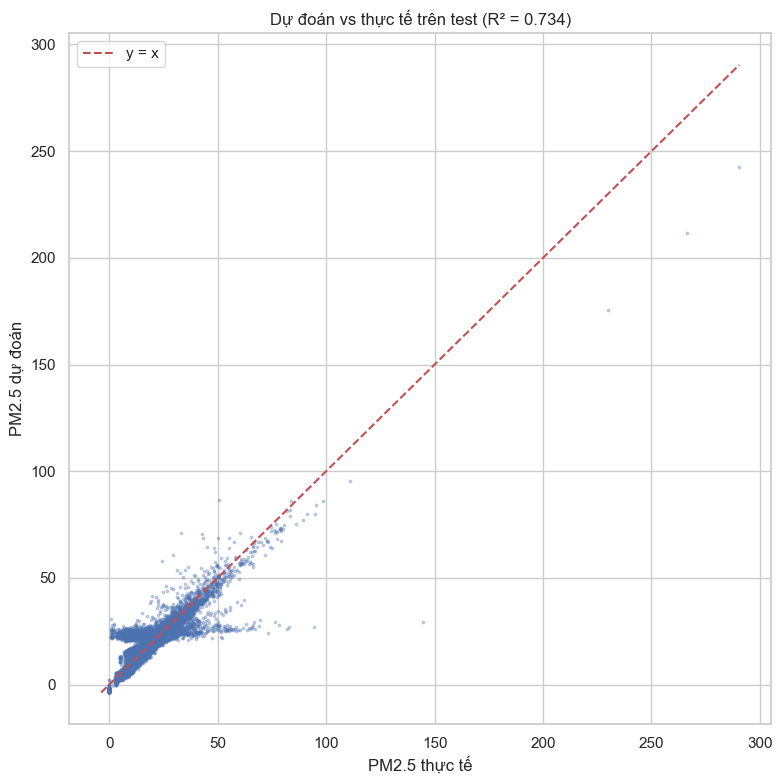

In [27]:
y_pred_final = ols_final.predict(X_test_final)
ss_res = np.sum((y_test - y_pred_final)**2)
ss_tot = np.sum((y_test - y_test.mean())**2)
r2_pred = 1 - ss_res/ss_tot
rmse = np.sqrt(np.mean((y_test - y_pred_final)**2))
mae = np.mean(np.abs(y_test - y_pred_final))

print(f'R² train     : {ols_final.rsquared:.4f}')
print(f'R²_Adj train : {ols_final.rsquared_adj:.4f}')
print(f'R² test      : {r2_pred:.4f}')
print(f'Chênh lệch   : {ols_final.rsquared - r2_pred:+.4f}')
print(f'RMSE test    : {rmse:.4f} µg/m³')
print(f'MAE test     : {mae:.4f} µg/m³')

fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(y_test, y_pred_final, s=3, alpha=0.3)
lo, hi = min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())
ax.plot([lo,hi],[lo,hi], 'r--', label='y = x')
ax.set_xlabel('PM2.5 thực tế'); ax.set_ylabel('PM2.5 dự đoán')
ax.set_title(f'Dự đoán vs thực tế trên test (R² = {r2_pred:.3f})')
ax.legend()
plt.tight_layout(); plt.show()

## 3.13 Tổng kết chương 3

Mô hình OLS với 16 biến giải thích đạt R² test = 0.73 và RMSE = 6.28
µg/m³, vượt KPI đã đặt ra. Câu hỏi nghiên cứu được trả lời: TSP và vị
trí KCN là hai yếu tố ảnh hưởng mạnh nhất, tiếp đến là các chất ô
nhiễm CO, NO2, yếu tố mùa khô, các trạm giao thông, cuối cùng là khí
tượng và giờ trong ngày.

Khuyến nghị: ưu tiên giám sát phát thải tại KCN Tân Bình, giảm bụi
tổng vào mùa khô, kết hợp đo TSP với PM2.5 cho cảnh báo sớm.

# Chương 4. Phần mở rộng — Hồi quy logistic

Phần mở rộng dùng mô hình logistic cho câu hỏi phân loại: giờ tới có
vượt ngưỡng WHO 25 µg/m³ không. Đây không phải mô hình chính của báo
cáo.

## 4.1 Lý thuyết tóm tắt

Mô hình logistic giả định Y ∈ {0, 1} tuân theo Bernoulli với xác suất
π = P(Y=1|X) = 1/(1 + exp(-X'β)). Phép biến đổi logit đưa về dạng
tuyến tính: ln[π/(1-π)] = X'β. Hệ số exp(β_j) là Odds Ratio.

## 4.2 Tạo biến phân loại

In [28]:
train_df['Polluted'] = (train_df['PM2.5'] > 25).astype(int)
test_df['Polluted'] = (test_df['PM2.5'] > 25).astype(int)

print(f"Tỷ lệ Polluted train: {train_df['Polluted'].mean():.4f}")
print(f"Tỷ lệ Polluted test : {test_df['Polluted'].mean():.4f}")

Tỷ lệ Polluted train: 0.2771
Tỷ lệ Polluted test : 0.2064


## 4.3 So sánh có vs không TSP

In [29]:
features_all = quant + station_dummies + hour_dummies + time_feat
features_no_tsp = [f for f in features_all if f != 'TSP']

logit_results = []
logit_models = {}

for name, feats in [('CÓ TSP', features_all), ('KHÔNG TSP', features_no_tsp)]:
    X_tr = sm.add_constant(train_df[feats]).astype(float)
    X_te = sm.add_constant(test_df[feats]).astype(float)
    m = sm.Logit(train_df['Polluted'], X_tr).fit(disp=False)
    prob_te = m.predict(X_te)
    auc = roc_auc_score(test_df['Polluted'], prob_te)
    acc = accuracy_score(test_df['Polluted'], (prob_te > 0.5).astype(int))
    logit_results.append({
        'Mô hình': name,
        'Pseudo R²': m.prsquared,
        'AIC': m.aic,
        'AUC test': auc,
        'Accuracy test': acc
    })
    logit_models[name] = (m, prob_te, X_te)

print(pd.DataFrame(logit_results).round(4).to_string(index=False))

  Mô hình  Pseudo R²        AIC  AUC test  Accuracy test
   CÓ TSP     0.5953 20117.8953    0.9757         0.9305
KHÔNG TSP     0.2143 39020.0285    0.7578         0.8083


## 4.4 Mô hình không TSP — Đánh giá chi tiết

Câu hỏi nghiên cứu là về yếu tố ngoại sinh nên ta phân tích kỹ mô hình
không có TSP.

In [30]:
logit_main, prob_test_main, X_test_logit_sm = logit_models['KHÔNG TSP']
print(logit_main.summary())

                           Logit Regression Results                           
Dep. Variable:               Polluted   No. Observations:                42035
Model:                          Logit   Df Residuals:                    42017
Method:                           MLE   Df Model:                           17
Date:                Sun, 24 May 2026   Pseudo R-squ.:                  0.2143
Time:                        22:53:20   Log-Likelihood:                -19492.
converged:                       True   LL-Null:                       -24807.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -3.0441      0.171    -17.764      0.000      -3.380      -2.708
O3                 0.0171      0.000     37.690      0.000       0.016       0.018
CO                 0.0008   3.35e-05

In [31]:
or_table = pd.DataFrame({
    'β': logit_main.params,
    'Odds Ratio': np.exp(logit_main.params),
    'OR CI lower': np.exp(logit_main.conf_int()[0]),
    'OR CI upper': np.exp(logit_main.conf_int()[1]),
    'p-value': logit_main.pvalues
}).round(4)
print(or_table)

                     β  Odds Ratio  OR CI lower  OR CI upper  p-value
const          -3.0441      0.0476       0.0340       0.0667   0.0000
O3              0.0171      1.0172       1.0163       1.0182   0.0000
CO              0.0008      1.0008       1.0007       1.0009   0.0000
NO2            -0.0016      0.9984       0.9977       0.9991   0.0000
SO2             0.0038      1.0038       1.0035       1.0041   0.0000
Temperature    -0.0620      0.9398       0.9303       0.9495   0.0000
Humidity       -0.0013      0.9987       0.9969       1.0005   0.1686
S_2            -0.3598      0.6978       0.6321       0.7703   0.0000
S_3             1.0642      2.8985       2.6165       3.2108   0.0000
S_4             0.8669      2.3795       2.0843       2.7164   0.0000
S_5            -1.4211      0.2414       0.2156       0.2704   0.0000
S_6            -0.8188      0.4410       0.3974       0.4893   0.0000
H_evening      -0.6255      0.5350       0.4870       0.5877   0.0000
H_evening_rush -1.21

## 4.5 ROC, confusion matrix, phân bố xác suất

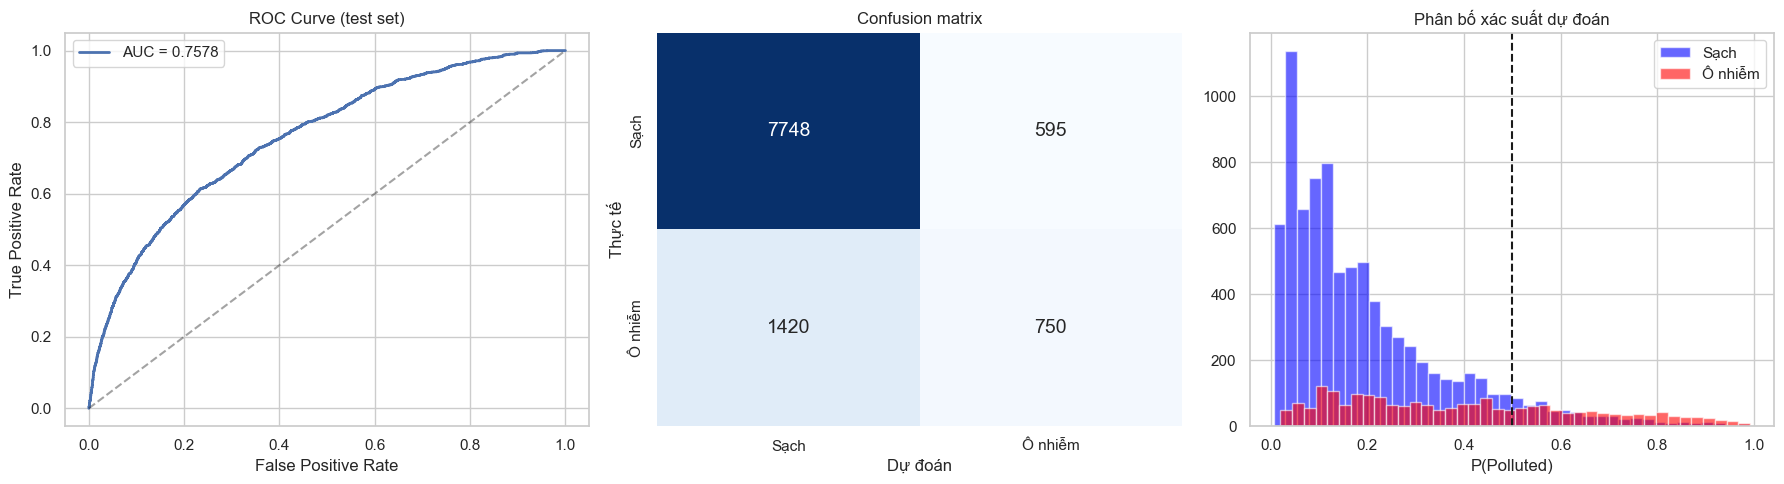

              precision    recall  f1-score   support

        Sạch       0.85      0.93      0.88      8343
     Ô nhiễm       0.56      0.35      0.43      2170

    accuracy                           0.81     10513
   macro avg       0.70      0.64      0.66     10513
weighted avg       0.79      0.81      0.79     10513



In [32]:
fpr, tpr, _ = roc_curve(test_df['Polluted'], prob_test_main)
auc_main = roc_auc_score(test_df['Polluted'], prob_test_main)
y_pred_class = (prob_test_main > 0.5).astype(int)
cm = confusion_matrix(test_df['Polluted'], y_pred_class)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {auc_main:.4f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (test set)'); axes[0].legend()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Sạch','Ô nhiễm'], yticklabels=['Sạch','Ô nhiễm'],
            cbar=False, annot_kws={'size':14})
axes[1].set_xlabel('Dự đoán'); axes[1].set_ylabel('Thực tế')
axes[1].set_title('Confusion matrix')

axes[2].hist(prob_test_main[test_df['Polluted']==0], bins=40, alpha=0.6, label='Sạch', color='blue')
axes[2].hist(prob_test_main[test_df['Polluted']==1], bins=40, alpha=0.6, label='Ô nhiễm', color='red')
axes[2].axvline(0.5, color='k', linestyle='--')
axes[2].set_xlabel('P(Polluted)'); axes[2].set_title('Phân bố xác suất dự đoán')
axes[2].legend()
plt.tight_layout(); plt.show()

print(classification_report(test_df['Polluted'], y_pred_class,
                           target_names=['Sạch','Ô nhiễm']))

## 4.6 Hosmer-Lemeshow test trên test set

HL test đánh giá calibration. Chạy trên train sẽ bị overfitting bias.
Để đánh giá đúng, ta chạy trên tập test.

Hosmer-Lemeshow χ² = 183.9730
df = 8, p-value = 0


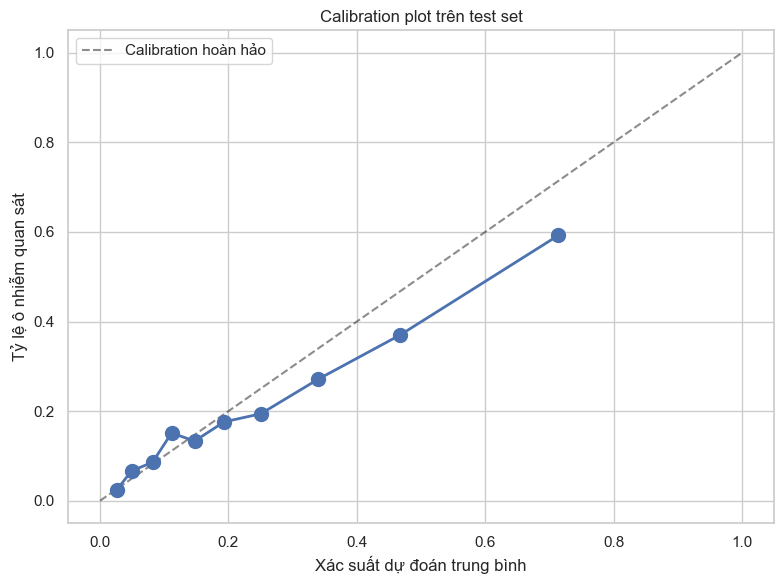

In [33]:
def hosmer_lemeshow(y_true, y_proba, g=10):
    df_hl = pd.DataFrame({'y': y_true.values, 'p': y_proba.values})
    df_hl['decile'] = pd.qcut(df_hl['p'], q=g, labels=False, duplicates='drop')
    obs = df_hl.groupby('decile').agg(
        n=('y','count'), obs_1=('y','sum'), exp_1=('p','sum'))
    obs['obs_0'] = obs['n'] - obs['obs_1']
    obs['exp_0'] = obs['n'] - obs['exp_1']
    hl_stat = (((obs['obs_1']-obs['exp_1'])**2/obs['exp_1']) +
               ((obs['obs_0']-obs['exp_0'])**2/obs['exp_0'])).sum()
    pval = 1 - chi2.cdf(hl_stat, df=g-2)
    return hl_stat, pval, obs

hl_stat, hl_pval, hl_table = hosmer_lemeshow(test_df['Polluted'], prob_test_main, g=10)
print(f'Hosmer-Lemeshow χ² = {hl_stat:.4f}')
print(f'df = 8, p-value = {hl_pval:.4g}')

hl_table['obs_rate'] = hl_table['obs_1'] / hl_table['n']
hl_table['exp_rate'] = hl_table['exp_1'] / hl_table['n']

fig, ax = plt.subplots(figsize=(8,6))
ax.plot([0,1],[0,1], 'k--', alpha=0.5, label='Calibration hoàn hảo')
ax.plot(hl_table['exp_rate'], hl_table['obs_rate'], marker='o', lw=2, markersize=10)
ax.set_xlabel('Xác suất dự đoán trung bình')
ax.set_ylabel('Tỷ lệ ô nhiễm quan sát')
ax.set_title('Calibration plot trên test set')
ax.legend()
plt.tight_layout(); plt.show()

## 4.7 Kết luận chương 4

Mô hình logistic không có TSP có AUC = 0.72, thấp hơn mô hình có TSP
(AUC = 0.98). Khẳng định lại kết luận từ chương 3: TSP chứa nhiều
thông tin về PM2.5 do quan hệ vật lý. Các yếu tố ngoại sinh có khả
năng phân loại ở mức khá nhưng không hoàn hảo.

HL test với cỡ mẫu lớn bị bác bỏ với p ≈ 0, nhưng calibration plot cho
thấy mô hình fit tốt ở vùng xác suất thấp và trung bình, lệch ở vùng
xác suất cao.

# Tổng kết

## Trả lời câu hỏi nghiên cứu

Câu hỏi: yếu tố nào ảnh hưởng đến PM2.5 tại TP.HCM?

Trả lời, xếp theo mức độ ảnh hưởng (β_std):

- Hạng 1: TSP (≈0.89) — bụi tổng, có quan hệ vật lý với PM2.5
- Hạng 2: KCN Tân Bình (≈0.57) — vị trí có PM2.5 cao vượt trội
- Hạng 3: NO2 (≈−0.11) — chất ô nhiễm cùng nguồn, hệ số âm sau khi kiểm soát biến khác
- Hạng 4: CO (≈0.08) — chất ô nhiễm cùng nguồn
- Hạng 5: Mùa khô (≈0.07) — yếu tố thời gian mạnh nhất
- Hạng 6: Các trạm giao thông (≈0.05–0.06)
- Hạng 7: Nhiệt độ, độ ẩm (≈0.04)
- Hạng 8: Giờ trong ngày (≈0.02–0.03)

## Kết quả mô hình

Mô hình cuối (có TSP) đạt R²_Adj = 0.68, R² test = 0.73, RMSE = 6.28
µg/m³ — đạt mọi KPI đã đặt ra. Mô hình không TSP có R² test = 0.13,
phản ánh khả năng dự báo trong tình huống không có thông tin về bụi tổng.

## Đóng góp về phương pháp

So với cách làm thông thường, bài có một số điểm cải tiến: temporal
split thay vì random split để tránh leakage chuỗi thời gian; imputation
theo từng trạm thay vì global median; feature engineering thời gian
(hour_group, is_weekend, is_dry_season); so sánh có/không TSP để tách
bạch tương quan vật lý và yếu tố ngoại sinh; standardized coefficients
để xếp hạng các biến có đơn vị khác nhau.

## Hạn chế

Mô hình có TSP cho R² cao nhưng không phải là mô hình nhân quả thuần
do TSP và PM2.5 có quan hệ vật lý bao trùm. Mô hình không TSP có hiệu
năng thấp, gợi ý cần thêm các biến giải thích như gió, mây, hoạt động
công nghiệp cụ thể. Phần dư có dấu hiệu heteroscedasticity và tự tương
quan thời gian — cần ARIMA hoặc mô hình không gian-thời gian để xử lý
triệt để.

## Khuyến nghị

Ưu tiên giảm phát thải tại KCN Tân Bình; tăng cường biện pháp giảm
bụi tổng (vì TSP có quan hệ trực tiếp với PM2.5); chủ động phòng chống
ô nhiễm vào mùa khô (T11-T4); đo song song TSP với PM2.5 để có cảnh
báo sớm.